In [1]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv('/content/Sales Dataset.csv')
df.head()


,Unnamed: 0,Date,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,0,2023-11-24,Male,34,Beauty,3,50,150
1,1,2023-02-27,Female,26,Clothing,2,500,1000
2,2,2023-01-13,Male,50,Electronics,1,30,30
3,3,2023-05-21,Male,37,Clothing,1,500,500
4,4,2023-05-06,Male,30,Beauty,2,50,100


In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Unnamed: 0        1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Gender            1000 non-null   object        
 3   Age               1000 non-null   int64         
 4   Product Category  1000 non-null   object        
 5   Quantity          1000 non-null   int64         
 6   Price per Unit    1000 non-null   int64         
 7   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(2)
memory usage: 62.6+ KB


In [9]:
df.duplicated().sum()

np.int64(0)

In [7]:
# Convert text columns to lowercase and remove extra spaces
df['Gender'] = df['Gender'].str.lower().str.strip()
df['Product Category'] = df['Product Category'].str.lower().str.strip()

In [8]:
print('Unique values in Gender column:', df['Gender'].unique())
print('Unique values in Product Category column:', df['Product Category'].unique())

Unique values in Gender column: ['male' 'female']
Unique values in Product Category column: ['beauty' 'clothing' 'electronics']


### Outlier Detection using IQR Method

In [11]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f'Number of outliers in {col}: {len(outliers)}')
    if not outliers.empty:
        display(outliers[[col]].head())


Number of outliers in Age: 0
Number of outliers in Quantity: 0
Number of outliers in Price per Unit: 0
Number of outliers in Total Amount: 0


In [12]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df['Age'] = 2025 - df['Age']

In [17]:
df.to_csv("cleaned_dataset.csv", index=False)


In [18]:
cleaned_df = pd.read_csv('cleaned_dataset.csv')
display(cleaned_df.head())

,Unnamed: 0,Date,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,0,2023-11-24,male,1991,beauty,3,50,150
1,1,2023-02-27,female,1999,clothing,2,500,1000
2,2,2023-01-13,male,1975,electronics,1,30,30
3,3,2023-05-21,male,1988,clothing,1,500,500
4,4,2023-05-06,male,1995,beauty,2,50,100


1. Descriptive Statistics & Univariate Analysis

In [21]:
df.describe()

,Unnamed: 0,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,499.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,0.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,249.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,499.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,749.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,999.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [24]:
np.mean(df['Total Amount'])

np.float64(456.0)

In [25]:
np.median(df['Total Amount'])

np.float64(135.0)

In [26]:
np.min(df['Total Amount'])

25

In [27]:
np.max(df['Total Amount'])

2000

In [30]:
np.std(df['Total Amount'])

559.7175627046198

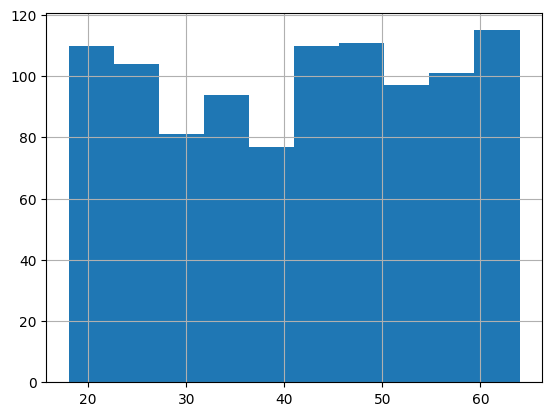

In [31]:
import matplotlib.pyplot as plt

df['Age'].hist()
plt.show()

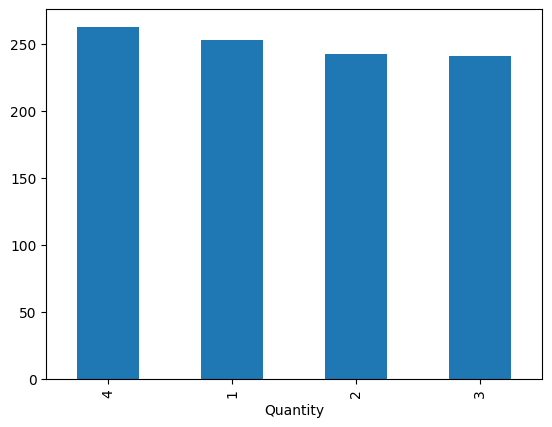

In [32]:
df['Quantity'].value_counts().plot(kind='bar')
plt.show()

Multivariate Analysis & **Correlation**

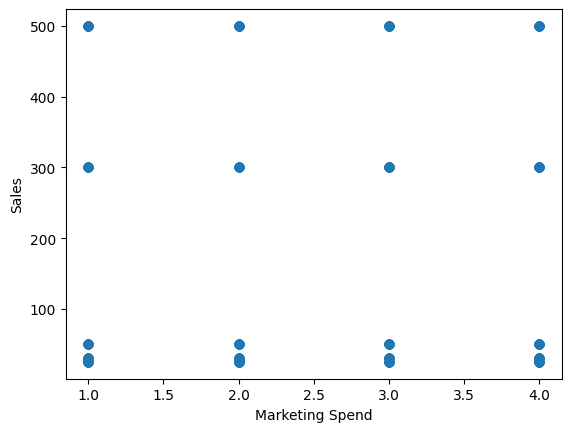

In [33]:
plt.scatter(df['Quantity'], df['Price per Unit'])
plt.xlabel("Marketing Spend")
plt.ylabel("Sales")
plt.show()

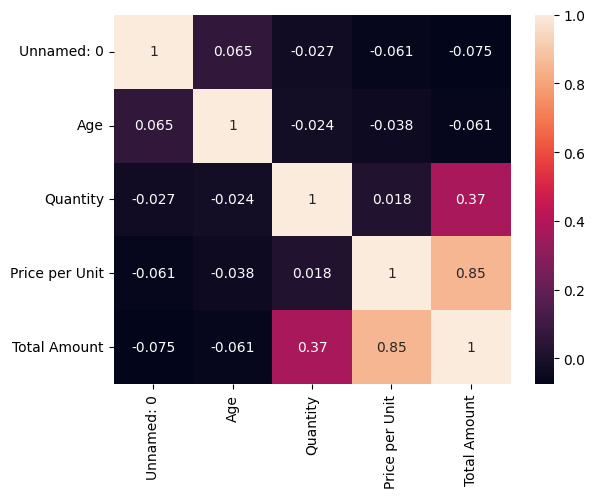

In [35]:
import seaborn as sns
numerical_df = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True)
plt.show()

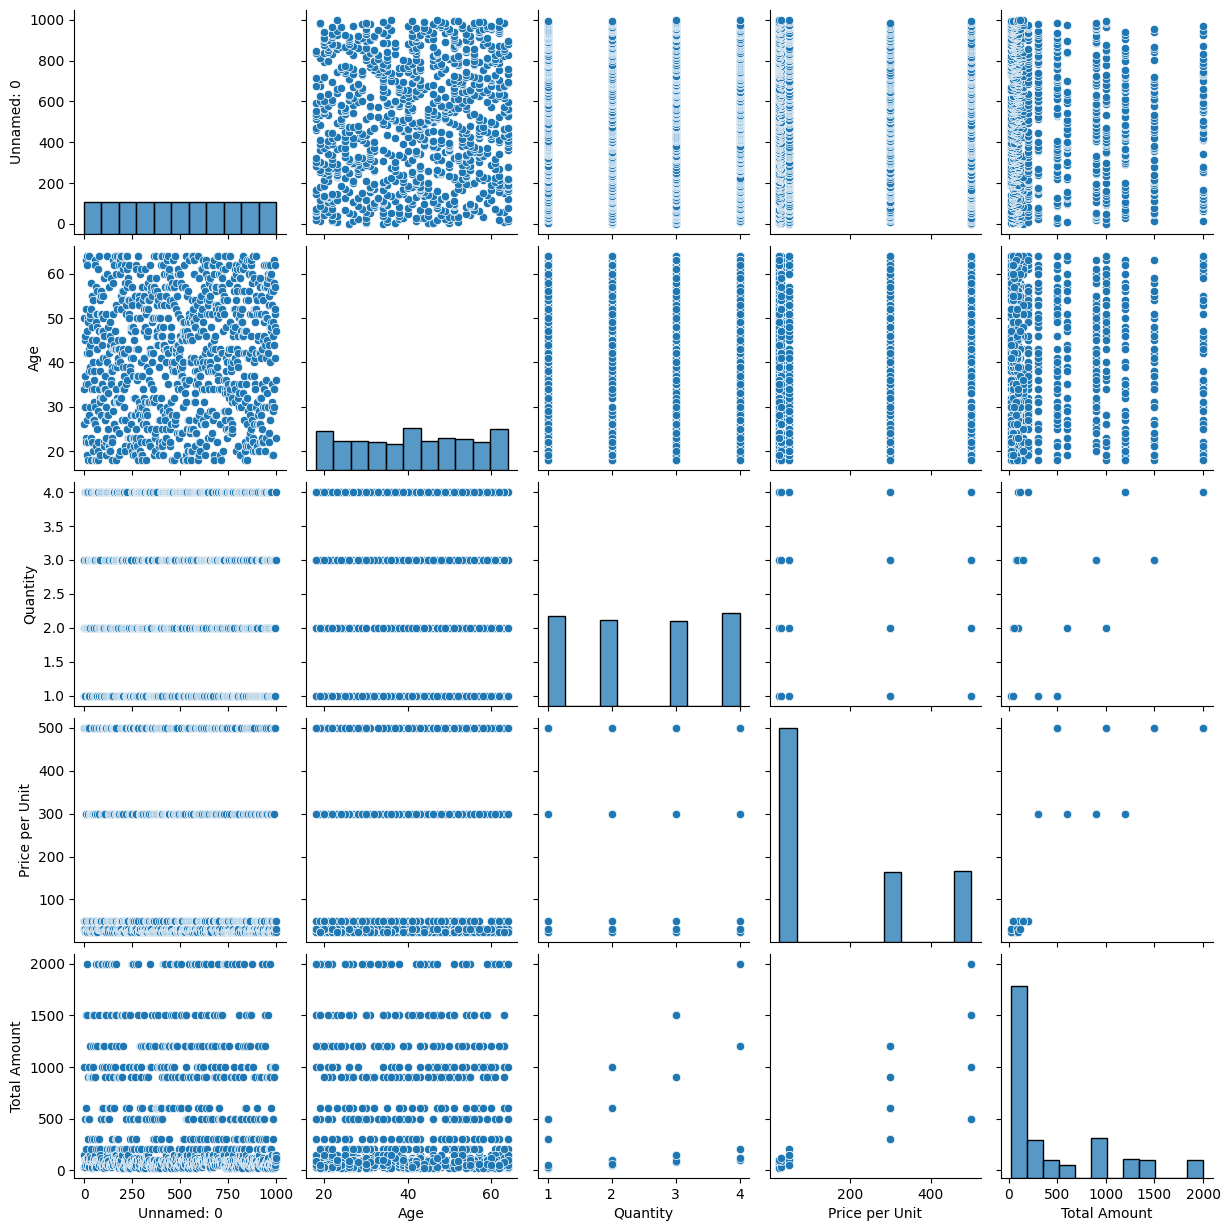

In [36]:
sns.pairplot(df)